In [2]:
#import packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import glob
from scipy.stats import skew
from scipy.interpolate import CubicSpline

In [3]:
# INPUT USER: Write data and figure paths

path = '/Users/laureleblanc/Desktop/Collective-twitching-2026/2_collective_organization/tessellation_postprocessing' 
data_path = path + '/dataset'
figure_path = "/Users/laureleblanc/Desktop/Collective-twitching-2026/2_collective_organization/tessellation_postprocessing/figures"

In [4]:
# Create a DataFrame with all experimental data
folder_list = [f for f in os.listdir(data_path) if (os.path.isdir(os.path.join(data_path, f)) and f[:6].isdigit())]
exp = pd.DataFrame(folder_list, columns=['folderpath'])

#Extract date and strain
exp_date = [exp.folderpath[i][:6] for i in range(len(exp.folderpath))]
exp_strain = [exp.folderpath[i][7:10] for i in range(len(exp.folderpath))]
exp['date'] = exp_date
exp['strain'] = exp_strain

# 1. Histogram: area

In [5]:
bin_edges = list(range(100))
bin_edges_norm = list(np.linspace(0,10,101))

def get_area_hist(path, filename, n_strain=0, n_replica=0):
  df = pd.read_csv(path+filename)
  df.columns = ['cellid', 'area', 'area_mean', 'area_norm']
  counts, _, _ = plt.hist(df['area'], bins=bin_edges, density=True)
  counts_norm, _, _ = plt.hist(df['area_norm'], bins=bin_edges_norm, density=True)
  plt.close()
  return counts, counts_norm, np.std(df['area']), np.std(df['area_norm']), df['area_norm'].max(), df['area_norm'].mean(), df['area_norm'].quantile(0.95), skew(df['area_norm'].dropna()), df['area_norm'].median()


In [6]:
# Get histogram from all experiments
exp['area_hist'] = [[] for _ in range(len(exp))]
exp['area_hist_norm'] = [[] for _ in range(len(exp))]
exp['area_hist_std'] = [[] for _ in range(len(exp))]
exp['area_hist_norm_std'] = [[] for _ in range(len(exp))]
exp['area_hist_norm_max'] = [[] for _ in range(len(exp))]
exp['area_hist_norm_max-mean'] = [[] for _ in range(len(exp))]
exp['area_hist_norm_cv'] = [[] for _ in range(len(exp))] # coefficient of variation = std / mean
exp['area_hist_norm_95pc'] = [[] for _ in range(len(exp))] # 95th percentile
exp['area_hist_norm_skew'] = [[] for _ in range(len(exp))] # skewness
exp['area_hist_norm_median'] = [[] for _ in range(len(exp))] # median


for n in range(len(exp)):
    path = data_path + '/' +  exp.folderpath[n] + '/tessellation/'
    filename = 'frame_0_voronoi_areas_microns.csv'

    a, b, c, d, e, f, g, h, i = get_area_hist(path, filename)
    exp.at[n, 'area_hist'] = a
    exp.at[n, 'area_hist_norm'] = b
    exp.at[n, 'area_hist_std'] = c
    exp.at[n, 'area_hist_norm_std'] = d
    exp.at[n, 'area_hist_norm_max'] = e
    exp.at[n, 'area_hist_norm_max'] = e
    exp.at[n, 'area_hist_norm_cv'] = d/f
    exp.at[n, 'area_hist_norm_95pc'] = g
    exp.at[n, 'area_hist_norm_skew'] = h
    exp.at[n, 'area_hist_norm_median'] = i

# 2. Surface coverage

In [7]:
# Extract surface coverage from all experiments
exp['surface_coverage'] = [range(0,len(bin_edges)-1) for _ in range(len(exp))]

for n in range(len(exp)):
  path = data_path + '/' +  exp.folderpath[n] + '/surface_coverage/'
  filename = 'surface_coverage_and_density.csv'
  df = pd.read_csv(path+filename)
  exp.at[n, 'surface_coverage'] = float(df.iloc[:,1])


/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73599/4054424984.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp.at[n, 'surface_coverage'] = float(df.iloc[:,1])
/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73599/4054424984.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp.at[n, 'surface_coverage'] = float(df.iloc[:,1])
/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73599/4054424984.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp.at[n, 'surface_coverage'] = float(df.iloc[:,1])
/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73599/4054424984.py:8: FutureWarning: Calling float on a single element Series is deprecated and will ra

# 3. Plots

## Skewness vs. surface coverage

/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73599/916221969.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = strain_data.groupby('surface_coverage_bin')['area_hist_norm_skew'].mean()


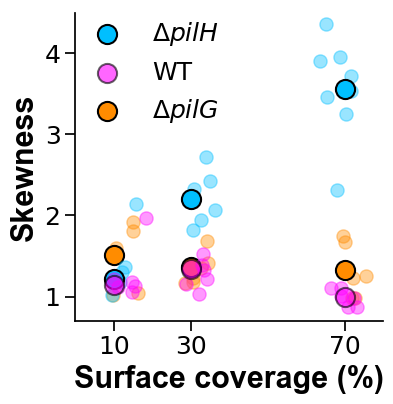

In [8]:
### Figure 1.D

# Define colors for each strain
color_map = {'177': 'magenta', '232': 'deepskyblue', '459': 'darkorange', '337': 'darksalmon', '436': 'mediumblue'}  

# Define bins and labels for surface coverage
bins = [0, 15, 40, 75]  # Define the edges of the bins
bin_labels = [10, 30, 70]  # Labels for the bins

# Add a new column to assign each point to a bin
exp['surface_coverage_bin'] = pd.cut(exp['surface_coverage'], bins=bins, labels=bin_labels)

# Formatting
plt.figure(figsize=(4,4))
legend_handles = []  # Store handles manually for legend ordering
legend_labels = []  # Store labels manually for legend ordering

for strain in ['459', '232', '177']: # Ensure the correct strain order
    strain_data = exp[exp['strain'] == strain]
    
    # Plot individual points with transparency
    plt.scatter(strain_data['surface_coverage'], strain_data['area_hist_norm_skew'], 
                color=color_map[strain], s=90, alpha=0.4)
    
    # Group by binned surface coverage and calculate the mean
    grouped = strain_data.groupby('surface_coverage_bin')['area_hist_norm_skew'].mean()
    
    # Assign legend labels in order
    if strain == '177': #WT
        label = 'WT'  
    elif strain == '459': #pilG-
        label = r'$\Delta\mathit{pilG}$' 
    elif strain == '232': #pilH-
        label = r'$\Delta\mathit{pilH}$'  

    # Set the alpha based on strain
    if strain == '177':  
        alpha_val = 0.6
    else:
        alpha_val = 1.0

    # Plot the averages with a black contour and store the handle for manual legend ordering
    scatter = plt.scatter(bin_labels, grouped.values, color=color_map[strain], s=190, alpha=alpha_val, 
                          edgecolors='black', linewidths=1.5, label=label)
    
    legend_handles.append(scatter)
    legend_labels.append(label)

# Manually set the legend with the correct order
desired_order = [r'$\Delta\mathit{pilH}$', 'WT', r'$\Delta\mathit{pilG}$']
ordered_handles_labels = sorted(zip(legend_handles, legend_labels), key=lambda x: desired_order.index(x[1]))
ordered_handles, ordered_labels = zip(*ordered_handles_labels)
plt.legend(ordered_handles, ordered_labels, loc='upper left', fontsize=18, frameon = False, bbox_to_anchor=(-0.05, 1.05)) #fontsize=16

# Add labels and formatting
plt.xlabel('Surface coverage (%)', fontsize=22, fontweight='bold', fontname='Arial')
plt.ylabel(r'Skewness', fontsize=22, fontweight='bold', fontname='Arial')
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.xlim([0, 80])
plt.ylim([0.7, 4.5])

# Plot appearance
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.25)
plt.gca().spines['bottom'].set_linewidth(1.25)
plt.gca().tick_params(axis='both', which='major', length=7, width=1.25, color='black')
plt.gca().tick_params(axis='both', which='minor', length=4, width=1.25, color='black')
plt.gca().set_box_aspect(1)
plt.xticks(ticks=[10, 30, 70]) 
plt.yticks(ticks=[1, 2, 3, 4])  # Ensure y-ticks are properly set

# Save the figure
plt.savefig(figure_path + '/skewness_norm_area_Figure1_plot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73599/616640446.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = strain_data.groupby('surface_coverage_bin')['area_hist_norm_skew'].mean()


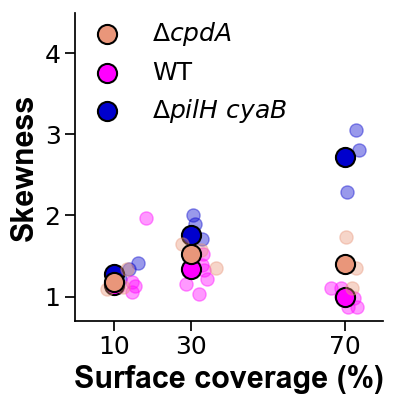

In [9]:
### Figure 2.E

# Define colors for each strain
color_map = {'177': 'magenta', '232': 'deepskyblue', '459': 'darkorange', '337': 'darksalmon', '436': 'mediumblue'}  

# Define bins and labels for surface coverage
bins = [0, 15, 40, 75]  # Define the edges of the bins
bin_labels = [10, 30, 70]  # Labels for the bins

# Add a new column to assign each point to a bin
exp['surface_coverage_bin'] = pd.cut(exp['surface_coverage'], bins=bins, labels=bin_labels)

# Formatting
plt.figure(figsize=(4,4))
legend_handles = []  # Store handles manually for legend ordering
legend_labels = []  # Store labels manually for legend ordering

for strain in ['436', '177', '337']: # Ensure the correct strain order
    strain_data = exp[exp['strain'] == strain]
    
    # Plot individual points with transparency
    plt.scatter(strain_data['surface_coverage'], strain_data['area_hist_norm_skew'], 
                color=color_map[strain], s=90, alpha=0.4)
    
    # Group by binned surface coverage and calculate the mean
    grouped = strain_data.groupby('surface_coverage_bin')['area_hist_norm_skew'].mean()
    
    # Assign legend labels in order
    if strain == '177': #WT
        label = 'WT'    
    elif strain == '337': #cpdA-
        label = r'$\Delta\mathit{cpdA}$'
    elif strain == '436': #pilH cyaB-
        label = r'$\Delta\mathit{pilH\ cyaB}$'

    # Set the alpha
    alpha_val = 1.0

    # Plot the averages with a black contour and store the handle for manual legend ordering
    scatter = plt.scatter(bin_labels, grouped.values, color=color_map[strain], s=190, alpha=alpha_val, 
                          edgecolors='black', linewidths=1.5, label=label)
    
    legend_handles.append(scatter)
    legend_labels.append(label)

# Manually set the legend with the correct order
desired_order = [r'$\Delta\mathit{cpdA}$', 'WT', r'$\Delta\mathit{pilH\ cyaB}$']
ordered_handles_labels = sorted(zip(legend_handles, legend_labels), key=lambda x: desired_order.index(x[1]))
ordered_handles, ordered_labels = zip(*ordered_handles_labels)
plt.legend(ordered_handles, ordered_labels, loc='upper left', fontsize=18, frameon = False, bbox_to_anchor=(-0.05, 1.05)) #fontsize=16

# Add labels and formatting
plt.xlabel('Surface coverage (%)', fontsize=22, fontweight='bold', fontname='Arial')
plt.ylabel(r'Skewness', fontsize=22, fontweight='bold', fontname='Arial')
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.xlim([0, 80])
plt.ylim([0.7, 4.5])

# Plot appearance
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.25)
plt.gca().spines['bottom'].set_linewidth(1.25)
plt.gca().tick_params(axis='both', which='major', length=7, width=1.25, color='black')
plt.gca().tick_params(axis='both', which='minor', length=4, width=1.25, color='black')
plt.gca().set_box_aspect(1)
plt.xticks(ticks=[10, 30, 70]) 
plt.yticks(ticks=[1, 2, 3, 4])  # Ensure y-ticks are properly set

# Save the figure
plt.savefig(figure_path + '/skewness_norm_area_Figure2_plot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [10]:
# Initialize data
data2plot = exp
data2plot = data2plot.sort_values(by=['strain', 'surface_coverage'], axis=0, ascending=True)
data2plot['bin_edges'] = [bin_edges[:-1] for _ in range (len(data2plot))]
data2plot['bin_edges_norm'] = [bin_edges_norm[:-1] for _ in range (len(data2plot))]

# Bin the surface coverage into categories
bins = [0, 25, 60, 100]
bins_label = ['Low', 'Medium', 'High']
data2plot['surface_coverage_bin'] = pd.cut(data2plot['surface_coverage'], bins=bins, labels=bins_label)

# Create a column for combined category
data2plot['strain_surface_coverage'] = data2plot['strain'] + '_' + data2plot['surface_coverage_bin'].astype(str)

data2plot

,folderpath,date,strain,area_hist,area_hist_norm,area_hist_std,area_hist_norm_std,area_hist_norm_max,area_hist_norm_max-mean,area_hist_norm_cv,area_hist_norm_95pc,area_hist_norm_skew,area_hist_norm_median,surface_coverage,surface_coverage_bin,bin_edges,bin_edges_norm,strain_surface_coverage
70,241018_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_m...,241018,177,"[0.0, 0.0, 0.0017921146953405018, 0.0, 0.00537...","[0.017921146953405017, 0.10752688172043011, 0....",14.918472,0.545039,3.540011,[],0.545039,2.018562,1.222627,0.908428,10.064518,Low,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",177_Low
20,240614_177_0p55agarose_2xTrpNC_OD0p5_1h30_5s_1...,240614,177,"[0.0, 0.0, 0.002717391304347826, 0.01766304347...","[0.01358695652173913, 0.23097826086956522, 0.4...",12.615089,0.599178,3.14645,[],0.599178,2.181639,1.119327,0.876423,11.082384,Low,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",177_Low
27,240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix...,240917,177,"[0.0, 0.0, 0.0, 0.0039164490861618795, 0.00783...","[0.0, 0.0391644908616188, 0.300261096605744, 0...",10.768248,0.528624,3.788534,[],0.528624,1.982819,1.1829,0.888834,14.705125,Low,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",177_Low
58,241003_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix...,241003,177,"[0.0, 0.0, 0.0012048192771084338, 0.0072289156...","[0.0, 0.060240963855421686, 0.2409638554216867...",10.06857,0.534652,3.419251,[],0.534652,2.028501,1.053777,0.885595,14.867017,Low,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",177_Low
69,240820_177_0p55pagarose_2xTrpNC_OD0p5_1h30_5s_...,240820,177,"[0.0, 0.0, 0.0012135922330097086, 0.0133495145...","[0.0, 0.0970873786407767, 0.3519417475728154, ...",10.535141,0.550827,3.627621,[],0.550827,2.070904,1.125159,0.889685,15.553645,Low,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",177_Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,240816_459_0p55pagarose_2xTrpNC_OD0p5_1h30_5s_...,240816,459,"[0.0, 0.063257065948856, 0.41261295904633727, ...","[0.0, 0.0, 0.0, 0.0, 0.055758507979234775, 0.3...",1.039972,0.32203,3.66836,[],0.32203,1.560606,1.679062,0.945886,70.209803,High,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",459_High
1,241018_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,241018,459,"[0.00018528812303131369, 0.06855660552158607, ...","[0.0, 0.0, 0.0018528812303131362, 0.0, 0.04817...",0.89971,0.28674,2.8125,[],0.28674,1.528982,0.983555,0.961371,71.789599,High,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",459_High
45,240524_459_0p55agarose_2xTrpNC_OD0p5_2h40_5s_1...,240524,459,"[0.000673551863493489, 0.015042658284687921, 0...","[0.0, 0.00224517287831163, 0.00673551863493488...",1.146315,0.303261,2.985739,[],0.303261,1.548549,1.224458,0.95451,72.276112,High,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",459_High
17,240614_459_0p55agarose_2xTrpNC_OD0p5_3h_5s_100...,240614,459,"[0.00014436263894903998, 0.27645445358741155, ...","[0.0, 0.0, 0.0, 0.0, 0.008661758336942401, 0.2...",0.670979,0.273217,2.628497,[],0.273217,1.497155,0.979697,0.960123,72.703669,High,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",459_High


## Voronoi Area Distribution - one condition at a time

In [11]:
# Custom function to draw each histogram and an overlay of the mean curve
def plot_records_and_mean(x, y, **kwargs):
  """
  Plots individual records and overlays a mean curve. The function handles both the case
  where there is only one record and the case where there are multiple records. It also
  allows for setting custom x-axis limits via keyword arguments.

  Parameters:
  ----------
  x : list or pandas Series
      List of x-coordinates for the records. If there is a single record, it can be a Series
      of x-values. If there are multiple records, it should be a list of lists/arrays.
  y : list or pandas Series
      List of y-coordinates for the records. If there is a single record, it can be a Series
      of y-values. If there are multiple records, it should be a list of lists/arrays.
  **kwargs : dict, optional
      Additional keyword arguments, including:
      - 'xlim1' (int or float): The lower limit for the x-axis (optional).
      - 'xlim2' (int or float): The upper limit for the x-axis (optional).

  Returns:
  -------
  None
      The function modifies the current matplotlib axis by plotting the individual records
      and overlaying the mean curve for the given data.

  Notes:
  ------
  - If the `x` or `y` inputs contain only one record, the plot will show the data
    without aggregation, and the mean curve will correspond to the given record.
  - If there are multiple records, the function will plot individual records as gray lines
    and overlay a mean curve based on the aggregated data.
  - The x-axis limits can be customized using `xlim1` and `xlim2`. If these are not provided,
    the axis limits will not be adjusted.
  """

  # Extracting xlim from kwargs if it is passed
  xlim1 = kwargs.get('xlim1', None)
  xlim2 = kwargs.get('xlim2', None)
  return_values = kwargs.get('return_values', False)

  fig, ax = plt.subplots(1, 1, figsize=(4,4))
  ax.set_yscale('log')
  #ax.set_xlim(right = 10)
  ax.set_xlim(right = xlim2)
  ax.set_ylim(bottom = 0.001, top = 10)
  #ax.set_xticks([0, 20, 40])
  #ax.set_xticks([0, 50, 100]) 
  ax.set_xticks([0, 5, 10]) 
  plt.gca().xaxis.set_minor_locator(plt.FixedLocator([1, 2, 3, 4, 5, 6, 7, 8, 9]))
  plt.gca().xaxis.set_major_locator(plt.FixedLocator([0, 5, 10]))
  ax.set_xlabel("Norm. Voronoi Area", fontsize=22, fontweight='bold', fontname='Arial')
  ax.set_ylabel("Probability", fontsize=22, fontweight='bold', fontname='Arial')
  ax.tick_params(axis='x', labelsize=18)
  ax.tick_params(axis='y', labelsize=18)
  ax.tick_params(axis='both', which='minor', length=5, width=1.25, color='black')
  ax.tick_params(axis='both', which='major', length=12, width=1.25, color='black')
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.spines['left'].set_linewidth(1.25)
  ax.spines['bottom'].set_linewidth(1.25)
  ax.set_box_aspect(1)

  if len(x)==1: # CASE 1: ONLY 1 DATA
    x_mean = x.to_list()[0]
    y_mean = y.to_list()[0]
    ax.plot(x_mean, y_mean, color='red', linewidth=7, label="Mean Curve", zorder = 1)

  else: #CASE 2: MORE THAN 1 DATA
    # Plot individual records
    for x_vals, y_vals in zip(x,y):
      ax.plot(x_vals, y_vals, linestyle='-', linewidth=2, color='gray', alpha=0.5, zorder = 2)

    # Compute mean data
    x_flattened = [val for sublist in x for val in sublist]
    x_mean = sorted(set(x_flattened))

    # Calculate mean y-values for each unique x
    y_mean = [
        np.mean([y_vals[x_vals.index(pt)] for x_vals, y_vals in zip(x, y) if pt in x_vals])
        for pt in x_mean
    ]

    # Plot the mean curve - Don't forget to update the color for each strain
    ax.plot(x_mean, y_mean, color='deepskyblue', linewidth=3, label="Mean Curve")

    # Set x-axis limits if provided
    if xlim1 is not None and xlim2 is not None:
        ax.set_xlim([xlim1, xlim2])

  # Return value of Mean Curve if specified
  if return_values is not False:
    return x_mean, y_mean

  # Save the log-log plot
  log_file_name = os.path.join(figure_path, "tesselation_232_norm_high.png") ### IMPORTANT: change the name of the file depending on the condition you want to plot (see cell below)
  plt.tight_layout()
  plt.savefig(log_file_name, bbox_inches='tight', dpi = 300, transparent=True)

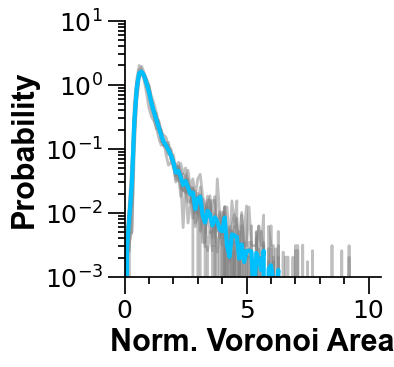

In [12]:
# Initialize the FacetGrid object -- graphes (1 condition at a time)

data2plot_temp = data2plot[data2plot['strain_surface_coverage']=='232_High'] ### Replace '232_High' by any other condition you want to plot. If this is the case, remember to update the figure filename in the cell above
plot_records_and_mean(data2plot_temp['bin_edges_norm'], data2plot_temp['area_hist_norm'], ylim1 = 0.001, xlim2 = 10.5)

## Voronoi Area Distribution - mean histograms

In [13]:
# Compute the mean area_hist for each strain and surface_coverage_bin
mean_data = data2plot.groupby(['surface_coverage_bin', 'strain']).agg(
    bin_edges=('bin_edges', 'first'),  # Take the first bin_edges for each group
    area_hist=('area_hist', lambda x: np.mean(np.array(list(x.tolist())), axis=0)),  # Mean of area_hist
    bin_edges_norm=('bin_edges_norm', 'first'),  # Take the first bin_edges_norm for each group
    area_hist_norm=('area_hist_norm', lambda x: np.mean(np.array(list(x.tolist())), axis=0))  # Mean of area_hist_norm
    ).reset_index()

# Associate colormap
mean_data['color'] = mean_data['strain'].map(color_map)

mean_data

/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73599/4109022360.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data = data2plot.groupby(['surface_coverage_bin', 'strain']).agg(


,surface_coverage_bin,strain,bin_edges,area_hist,bin_edges_norm,area_hist_norm,color
0,Low,177,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0, 0.002027253267341218, 0.01168018899...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.005251350579190691, 0.0906206632397023, 0.3...",magenta
1,Low,232,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.00022799817601459188, 0.0004559963520291837...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.023019320209715078, 0.3183789029928366, 0.6...",deepskyblue
2,Low,337,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.000505050505050505, 0.00101010101010101, 0....","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.03888579041953275, 0.21033959224143273, 0.6...",darksalmon
3,Low,436,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0011791687619485817, 0.012164554634022...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.004559963520291838, 0.2991068800407386, 0.6...",mediumblue
4,Low,459,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0, 0.00040828876097837567, 0.002726203...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.0, 0.07905150890014483, 0.325218666225325, ...",darkorange
5,Medium,177,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0005784112952324042, 0.027608971818119...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.0, 0.0017467436776864454, 0.061155849895557...",magenta
6,Medium,232,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0001968218126655911, 0.0020371257555023897,...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.0010070493454179255, 0.01937205691553549, 0...",deepskyblue
7,Medium,337,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0028606662688075344, 0.036636786635819...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.0, 0.007455056977734704, 0.1472018297749807...",darksalmon
8,Medium,436,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.006017206563825337, 0.0959314176243740...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.0, 0.0032434291375412726, 0.327787671532790...",mediumblue
9,Medium,459,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[9.667440061871616e-05, 0.000647064149850317, ...","[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...","[0.0, 0.005689585167536669, 0.0497062863889757...",darkorange


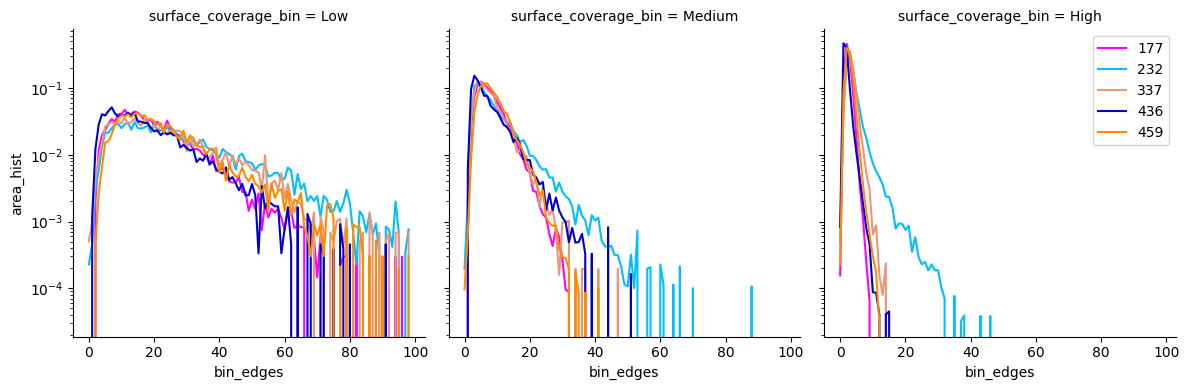

In [14]:
# --per surface coverage, strain overlay--

# Initialize the FacetGrid object with the surface_coverage_bin as columns
g = sns.FacetGrid(mean_data, col='surface_coverage_bin', col_wrap=3, height=4)

# Plot the mean value of area_hist for each strain within each facet
def plot_mean_hist(x, y, strain_color, **kwargs):
    for n in range(len(x)):
      plt.plot(x.iloc[n], y.iloc[n], color=strain_color.iloc[n])
    plt.yscale('log')

# Map the custom plot function onto the FacetGrid
g.map(plot_mean_hist, 'bin_edges', 'area_hist', strain_color=mean_data['color'])
plt.legend(mean_data['strain'].unique())

Saved: /Users/laureleblanc/Desktop/Collective-twitching-2026/2_collective_organization/tessellation_postprocessing/figures/tesselation_norm_177+232+459_density_low.png


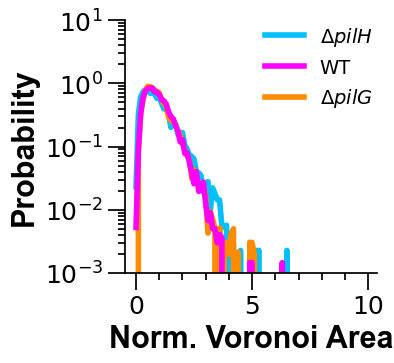

In [15]:
#Combined plot at low density
# -- per surface coverage, strain overlay --

mean_data_temp = mean_data[mean_data['surface_coverage_bin'] == 'Low']

fig, ax = plt.subplots(figsize=(4,4))

# Define strain labels (italic for pilH and pilG cpdA)
strain_labels = {
    '232': r'$\Delta\mathit{pilH}$', 
    '177': 'WT', 
    '459': r'$\Delta\mathit{pilG}$'
}

# Define plotting order
plot_order = ['232', '459', '177']

# Store handles for the legend
legend_handles = {}

# Plot the mean value of area_hist for each strain
for strain in plot_order:
    strain_data = mean_data_temp[mean_data_temp['strain'] == strain]

    for n in range(len(strain_data)):
        line, = ax.plot(
            strain_data.iloc[n]['bin_edges_norm'],
            strain_data.iloc[n]['area_hist_norm'], 
            color=strain_data.iloc[n]['color'],
            linewidth=4,
            label=strain_labels[strain]
        )

    # Store one legend handle per strain (avoid duplicates)
    if strain not in legend_handles:
        legend_handles[strain] = line

# Set log scale, limits, and labels
ax.set_yscale('log')
ax.set_ylim(0.001, 10)
ax.set_xlabel("Norm. Voronoi Area", fontsize=22, fontweight='bold', fontname='Arial')
ax.set_ylabel("Probability", fontsize=22, fontweight='bold', fontname='Arial')
ax.set_xticks([0, 5, 10])
ax.minorticks_on()
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='both', which='minor', length=5, width=1.25, color='black')
ax.tick_params(axis='both', which='major', length=12, width=1.25, color='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.25)
ax.spines['bottom'].set_linewidth(1.25)
ax.set_box_aspect(1)
fig.tight_layout()

# Set custom legend order (ΔpilH first, WT second, ΔpilG third)
ordered_legend_handles = [legend_handles['232'], legend_handles['177'], legend_handles['459']]
ordered_labels = [strain_labels['232'], strain_labels['177'], strain_labels['459']]
ax.legend(ordered_legend_handles, ordered_labels, loc='upper right', fontsize=14, frameon=False, bbox_to_anchor=(1.05, 1.05))

# Save the log-log plot
log_file_name = os.path.join(figure_path, "tesselation_norm_177+232+459_density_low.png")
plt.savefig(log_file_name, bbox_inches='tight', dpi=300, transparent=True)
print("Saved:", log_file_name)

# Show plot
plt.show()


Saved: /Users/laureleblanc/Desktop/Collective-twitching-2026/2_collective_organization/tessellation_postprocessing/figures/tesselation_norm_177+232+459_density_high.png


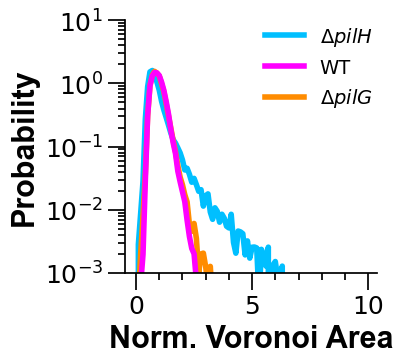

In [16]:
#Figure 1.C
#Combined plot at high density
# -- per surface coverage, strain overlay --

mean_data_temp = mean_data[mean_data['surface_coverage_bin'] == 'High']

fig, ax = plt.subplots(figsize=(4,4))

# Define strain labels (italic for pilH and pilG cpdA)
strain_labels = {
    '232': r'$\Delta\mathit{pilH}$', 
    '177': 'WT', 
    '459': r'$\Delta\mathit{pilG}$'
}

# Define plotting order
plot_order = ['232', '459', '177']

# Store handles for the legend
legend_handles = {}

# Plot the mean value of area_hist for each strain
for strain in plot_order:
    strain_data = mean_data_temp[mean_data_temp['strain'] == strain]

    for n in range(len(strain_data)):
        line, = ax.plot(
            strain_data.iloc[n]['bin_edges_norm'],
            strain_data.iloc[n]['area_hist_norm'], 
            color=strain_data.iloc[n]['color'],
            linewidth=4,
            label=strain_labels[strain]
        )

    # Store one legend handle per strain (avoid duplicates)
    if strain not in legend_handles:
        legend_handles[strain] = line

# Set log scale, limits, and labels
ax.set_yscale('log')
ax.set_ylim(0.001, 10)
ax.set_xlabel("Norm. Voronoi Area", fontsize=22, fontweight='bold', fontname='Arial')
ax.set_ylabel("Probability", fontsize=22, fontweight='bold', fontname='Arial')
ax.set_xticks([0, 5, 10])
ax.minorticks_on()
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='both', which='minor', length=5, width=1.25, color='black')
ax.tick_params(axis='both', which='major', length=12, width=1.25, color='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.25)
ax.spines['bottom'].set_linewidth(1.25)
ax.set_box_aspect(1)
fig.tight_layout()

# Set custom legend order (ΔpilH first, WT second, ΔpilG third)
ordered_legend_handles = [legend_handles['232'], legend_handles['177'], legend_handles['459']]
ordered_labels = [strain_labels['232'], strain_labels['177'], strain_labels['459']]
ax.legend(ordered_legend_handles, ordered_labels, loc='upper right', fontsize=14, frameon=False, bbox_to_anchor=(1.05, 1.05))

# Save the log-log plot
log_file_name = os.path.join(figure_path, "tesselation_norm_177+232+459_density_high.png")
plt.savefig(log_file_name, bbox_inches='tight', dpi=300, transparent=True)
print("Saved:", log_file_name)

# Show plot
plt.show()
